#  Life Expectancy Prediction using Linear Regression

### Problem Statement:
Life expectancy is a key indicator of a country’s overall health and socio-economic development. The objective of this project is to predict life expectancy using Linear Regression by analyzing factors such as health indicators, economic conditions, and demographic variables. The model aims to understand the relationship between these features and life expectancy and evaluate the prediction accuracy using regression performance metrics

### Steps to be followed:
1. Importing the required Libraries
2. Loading the dataset
3. Data Preprocessing
4. Checking Null values
5. Data Wrangling (Filling Null values)
6. Data Visualization
7. Label Encoding
8. Feature Selection (x,y)
9. Train-test split
10. Linear Regression Model Training and Prediction
11. Model Evaluation (R2 score,MAE,MSE,RMSE)
12. Regularization Techniques (Lasso,Ridge,ElasticNet)
13. Comparision Table for all Models
14. Scatter Chart (Actual vs Predicted values)

# Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import math
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error, mean_absolute_error, root_mean_squared_error

In [2]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler,MinMaxScaler


# Loading the Dataset 

In [3]:
df=pd.read_csv(r"C:\Users\HP\Downloads\Life Expectancy data.csv")
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


# Data Preprocessing

In [4]:
df.shape

(2938, 22)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [6]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [7]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [8]:
df.tail()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.0,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.0,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.0,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.0,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8
2937,Zimbabwe,2000,Developing,46.0,665.0,24,1.68,0.0,79.0,1483,...,78.0,7.10,78.0,43.5,547.358878,12222251.0,11.0,11.2,0.434,9.8


The dataset contains multiple numerical health indicators along with categorical features such as country and development status.

# Checking Null Values

In [9]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

<Axes: >

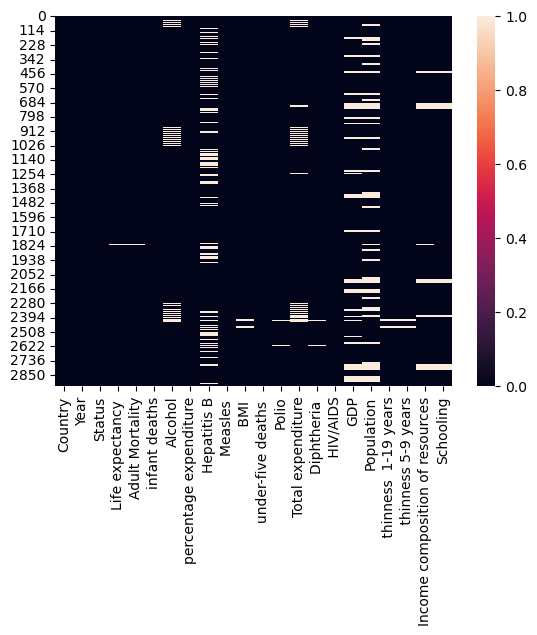

In [10]:
sns.heatmap(df.isnull())

In [11]:
df.isnull().any()

Country                            False
Year                               False
Status                             False
Life expectancy                     True
Adult Mortality                     True
infant deaths                      False
Alcohol                             True
percentage expenditure             False
Hepatitis B                         True
Measles                            False
 BMI                                True
under-five deaths                  False
Polio                               True
Total expenditure                   True
Diphtheria                          True
 HIV/AIDS                          False
GDP                                 True
Population                          True
 thinness  1-19 years               True
 thinness 5-9 years                 True
Income composition of resources     True
Schooling                           True
dtype: bool

In [13]:
df.isnull().sum() * 100/len(df)

Country                             0.000000
Year                                0.000000
Status                              0.000000
Life expectancy                     0.340368
Adult Mortality                     0.340368
infant deaths                       0.000000
Alcohol                             6.603131
percentage expenditure              0.000000
Hepatitis B                        18.822328
Measles                             0.000000
 BMI                                1.157250
under-five deaths                   0.000000
Polio                               0.646698
Total expenditure                   7.692308
Diphtheria                          0.646698
 HIV/AIDS                           0.000000
GDP                                15.248468
Population                         22.191967
 thinness  1-19 years               1.157250
 thinness 5-9 years                 1.157250
Income composition of resources     5.684139
Schooling                           5.547992
dtype: flo

Several features contain missing values which will be handled using median imputation for numerical features.

# Data Wrangling (Filling Null/Missing Values)

Numerical columns are filled using the median value to reduce the impact of outliers.

In [15]:
num_cols = ['Life expectancy ', 'Adult Mortality','Alcohol','Hepatitis B',' BMI ','Polio','Total expenditure','Diphtheria ','GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


In [16]:
df.dtypes

Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

<Axes: >

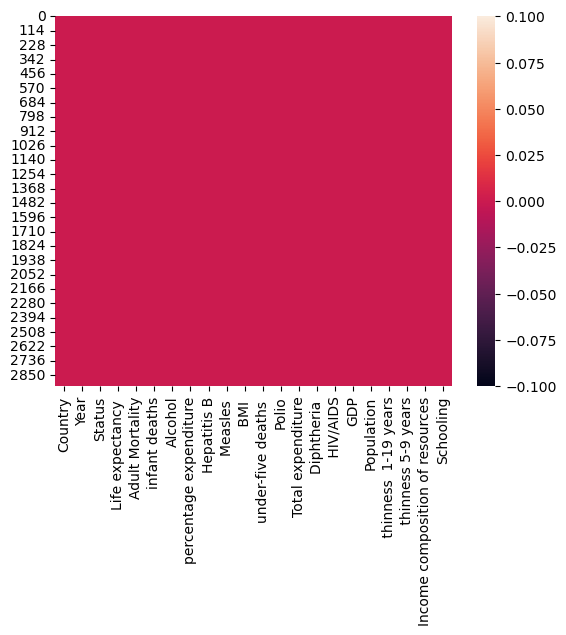

In [17]:
sns.heatmap(df.isnull())

In [18]:
df.isnull().sum()

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
dtype: int64

# Data Visualization

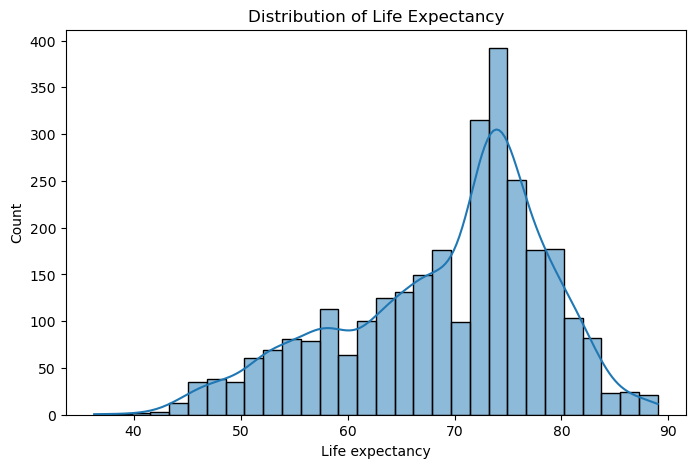

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['Life expectancy'], bins=30, kde=True)
plt.title('Distribution of Life Expectancy')
plt.show()

Life expectancy is mostly concentrated around 65–75 years with a few lower-value outliers, indicating most countries have similar average life spans.

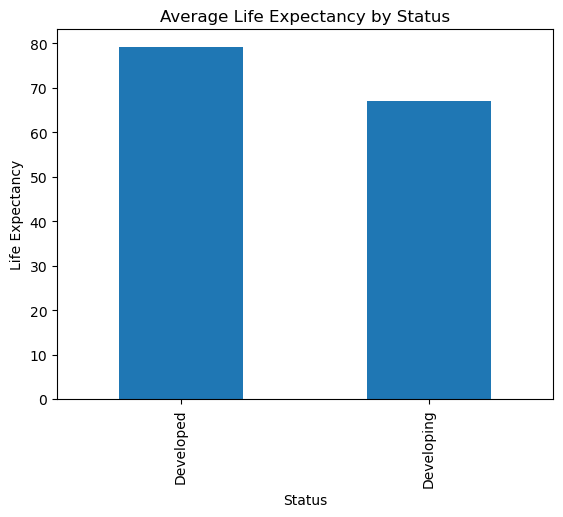

In [21]:
status_avg = df.groupby('Status')['Life expectancy'].mean()

status_avg.plot(kind='bar')
plt.title('Average Life Expectancy by Status')
plt.ylabel('Life Expectancy')
plt.show()

Developed countries have significantly higher life expectancy than developing countries, indicating the impact of better healthcare and living conditions

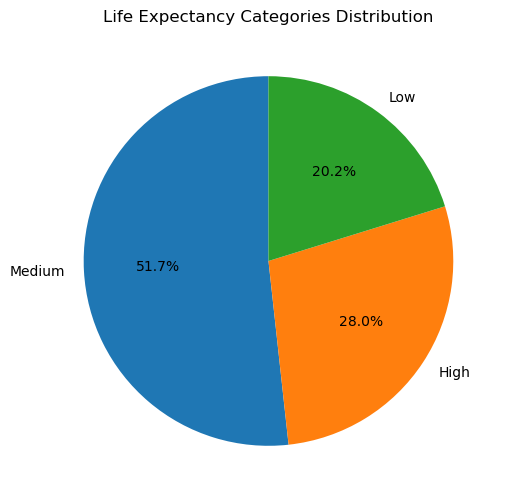

In [22]:
df['Life Category'] = pd.cut(df['Life expectancy'],
                             bins=[0,60,75,100],
                             labels=['Low','Medium','High'])

life_counts = df['Life Category'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(life_counts,
        labels=life_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title('Life Expectancy Categories Distribution')
plt.show()

Most countries fall into the medium life expectancy category, while fewer countries have very high or very low life expectancy.

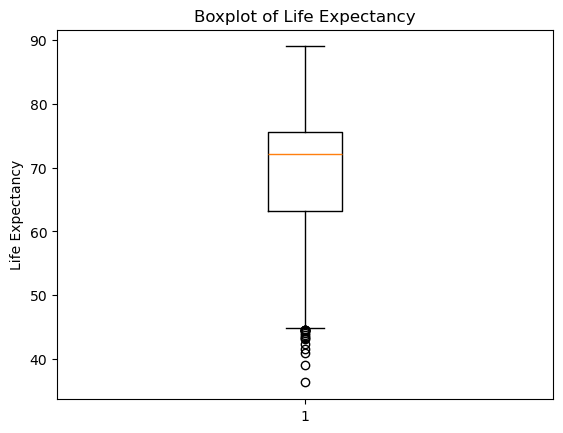

In [23]:
plt.figure()
plt.boxplot(df['Life expectancy'].dropna())
plt.title('Boxplot of Life Expectancy')
plt.ylabel('Life Expectancy')
plt.show()

Most life expectancy values lie between 63–75 years with a median around 72, while a few low outliers indicate countries with significantly lower life expectancy.

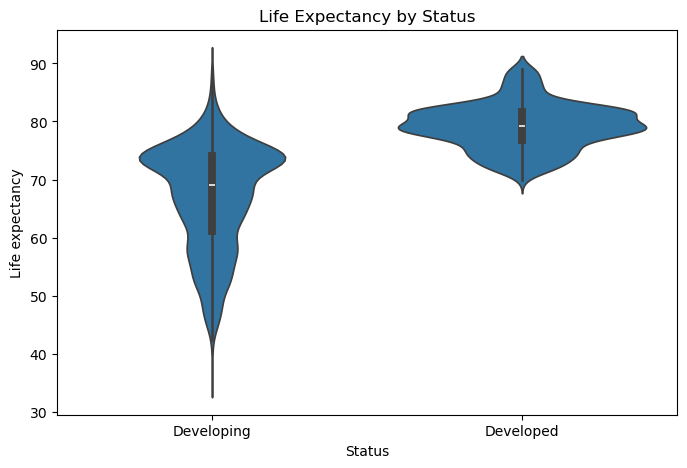

In [24]:
plt.figure(figsize=(8,5))
sns.violinplot(x='Status', y='Life expectancy', data=df)
plt.title('Life Expectancy by Status')
plt.show()

Developed countries show higher and more consistent life expectancy, while developing countries have lower and more widely spread life expectancy values.

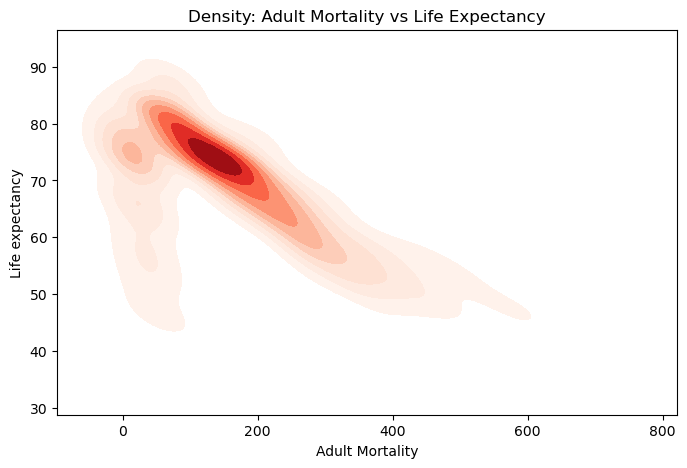

In [25]:
plt.figure(figsize=(8,5))
sns.kdeplot(
    x=df['Adult Mortality'],
    y=df['Life expectancy'],
    fill=True,
    cmap='Reds')
plt.title('Density: Adult Mortality vs Life Expectancy')
plt.show()

Higher adult mortality is associated with lower life expectancy, indicating a strong negative relationship between the two variables.

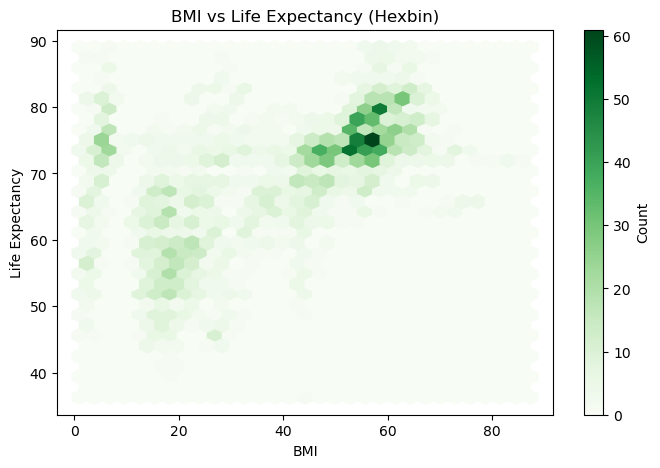

In [26]:
plt.figure(figsize=(8,5))
plt.hexbin(df['BMI'], df['Life expectancy'], gridsize=30, cmap='Greens')
plt.colorbar(label='Count')
plt.xlabel('BMI')
plt.ylabel('Life Expectancy')
plt.title('BMI vs Life Expectancy (Hexbin)')
plt.show()

Higher BMI levels (within normal range) are generally associated with higher life expectancy.

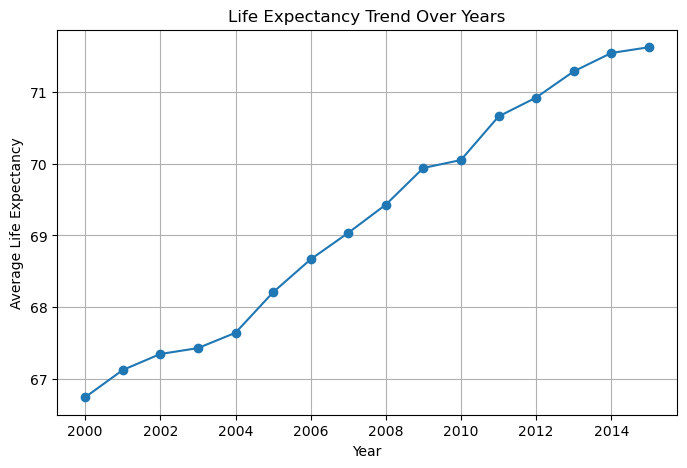

In [27]:
year_avg = df.groupby('Year')['Life expectancy'].mean()
plt.figure(figsize=(8,5))
plt.plot(year_avg.index, year_avg.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Average Life Expectancy')
plt.title('Life Expectancy Trend Over Years')
plt.grid(True)
plt.show()

Global life expectancy has gradually increased over the years, showing improvement in health conditions.

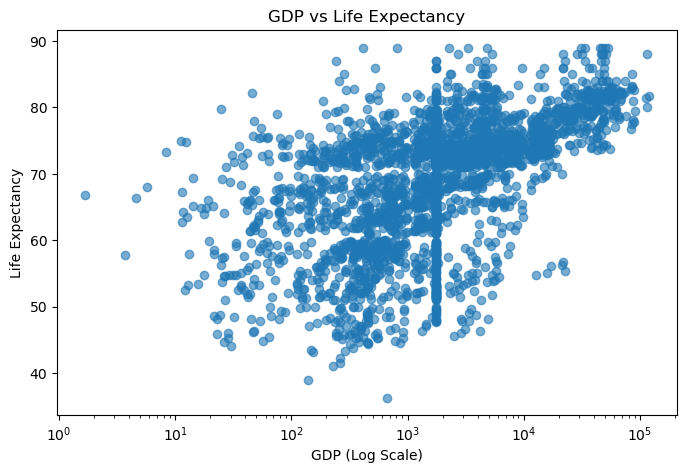

In [28]:
plt.figure(figsize=(8,5))
plt.scatter(df['GDP'], df['Life expectancy'], alpha=0.6)
plt.xscale('log')
plt.xlabel('GDP (Log Scale)')
plt.ylabel('Life Expectancy')
plt.title('GDP vs Life Expectancy')
plt.show()

Higher GDP is associated with higher life expectancy due to better economic and healthcare conditions.

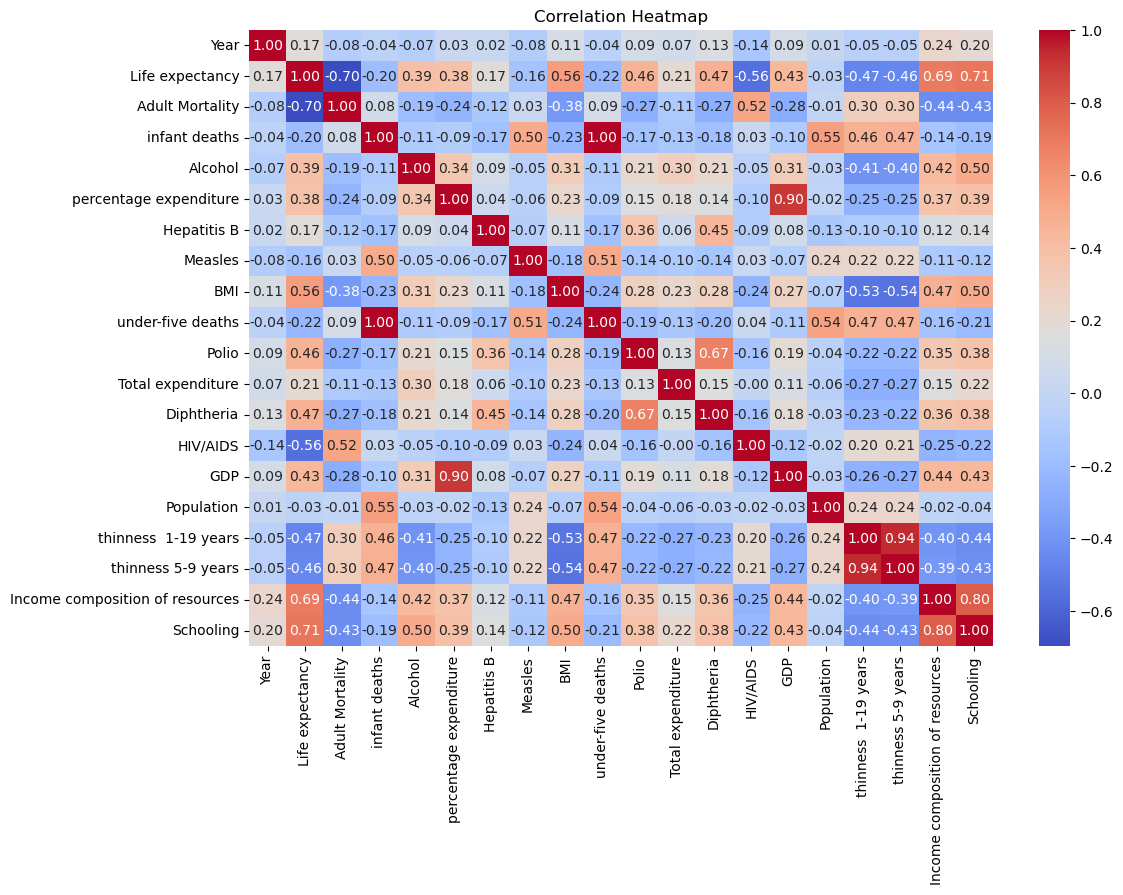

<Figure size 640x480 with 0 Axes>

In [29]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()
plt.tight_layout()

Education, income, and BMI positively influence life expectancy, while adult mortality and HIV/AIDS negatively impact it.

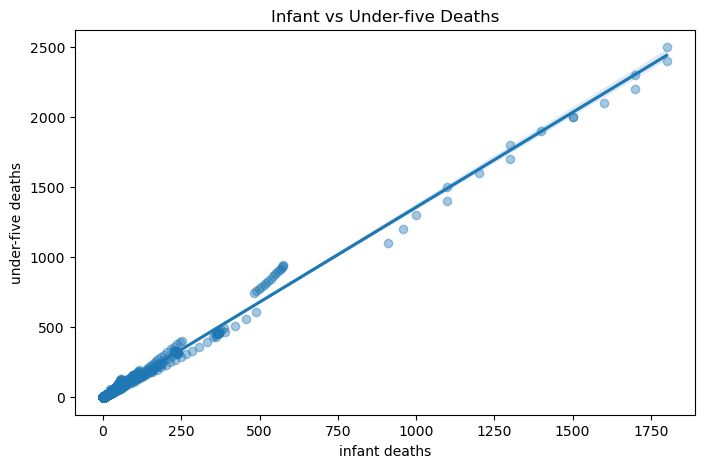

In [30]:
plt.figure(figsize=(8,5))
sns.regplot(x='infant deaths',
            y='under-five deaths',
            data=df,
            scatter_kws={'alpha':0.4})

plt.title('Infant vs Under-five Deaths')
plt.show()

Infant deaths strongly influence under-five deaths, indicating high dependency between the two variables.

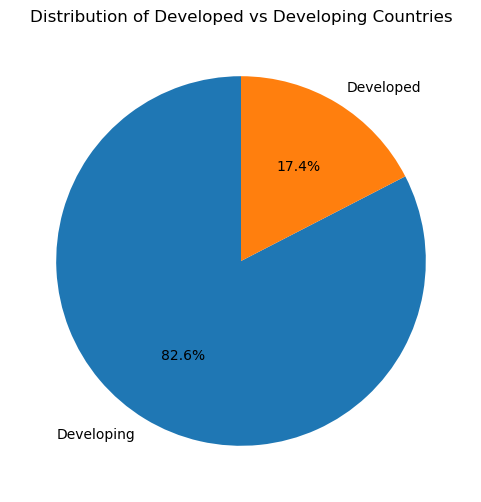

In [31]:
status_counts = df['Status'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(status_counts,
        labels=status_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title('Distribution of Developed vs Developing Countries')
plt.show()

The dataset mainly consists of developing countries, which may influence overall life expectancy patterns.

# Label Encoding

Categorical features such as country, status and life category are converted into numerical values using Label Encoding.

In [32]:
label = LabelEncoder()
cat_col = ['Country','Status','Life Category']
for col in cat_col:
    df[col] = df[col].astype(str)
    df[col] = label.fit_transform(df[col])

In [33]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling',
       'Life Category'],
      dtype='object')

# Feature Selection (x, y)

In [34]:
x=df.drop(columns=['Life expectancy'])
y=df['Life expectancy']

# Train-Test Split

The dataset is split into 80% training data and 20% testing data.

In [35]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=42)

In [36]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Model Training

In [37]:
LR = LinearRegression()

In [38]:
LR.fit(x_train, y_train)

LinearRegression()

# Model Prediction 

In [39]:
y_predict = LR.predict(x_test)

# Model Evaluation (Linear Regression)

### R2 Score

In [40]:
r2 = r2_score(y_test, y_predict)
r2*100

82.82998829938632

### Mean Absolute Error

In [41]:
mae = mean_absolute_error(y_test, y_predict)
mae

2.801571664288218

### Mean Squared Error

In [42]:
mse = mean_squared_error(y_test, y_predict)
mse

14.880796763476184

### Root Mean Squared Error

In [43]:
rmse = root_mean_squared_error(y_test, y_predict)
rmse

3.857563578669337

### Adjusted R2

In [44]:
n = x_test.shape[0]
p = x_test.shape[1]

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
adjusted_r2

0.8216142147210578

# Model Comparison: Ridge, Lasso and ElasticNet

## L1 Regularization (Lasso Regression)

In [45]:
l1 = Lasso()

In [46]:
l1.fit(x_train_scaled, y_train)
y_pred_l1 = l1.predict(x_test_scaled)

In [47]:
r2_l1 = r2_score(y_test, y_pred_l1)
r2_l1

0.7755100645941767

In [48]:
mae_l1 = mean_absolute_error(y_test, y_pred_l1)
mae_l1

3.1983232658542247

In [49]:
mse_l1 = mean_squared_error(y_test, y_pred_l1)
mse_l1 

19.4559512391046

In [50]:
rmse_l1 = root_mean_squared_error(y_test, y_pred_l1)
rmse_l1

4.4108900733417284

## L2 Regularization (Ridge Regression)

In [51]:
l2 = Ridge()
l2.fit(x_train_scaled, y_train)
y_pred_l2 = l2.predict(x_test_scaled)

In [52]:
r2_l2 = r2_score(y_test, y_pred_l2)
r2_l2

0.8277559452976384

In [53]:
mae_l2 = mean_absolute_error(y_test, y_pred_l2)
mae_l2

2.80538651236929

In [54]:
mse_l2 = mean_squared_error(y_test, y_pred_l2)
mse_l2 

14.927938410498031

In [55]:
rmse_l2 = root_mean_squared_error(y_test, y_pred_l2)
rmse_l2

3.863669034803322

## L12 Regularization (ElasticNet Regression)

In [56]:
l12 = ElasticNet()
l12.fit(x_train_scaled, y_train)
y_pred_l12 = l12.predict(x_test_scaled)

In [57]:
r2_l12 = r2_score(y_test, y_pred_l12)
r2_l12

0.7799168522551965

In [58]:
mae_l12 = mean_absolute_error(y_test, y_pred_l12)
mae_l12

3.188561043062621

In [59]:
mse_l12 = mean_squared_error(y_test, y_pred_l12)
mse_l12 

19.074026563065587

In [60]:
rmse_l12 = root_mean_squared_error(y_test, y_pred_l12)
rmse_l12

4.367382117821337

# Model Comparision Table

In [61]:
models = {
    "Linear Regression (LR)": LinearRegression(),
    "Lasso (L1)": Lasso(alpha=0.01),
    "Ridge (L2)": Ridge(alpha=1.0),
    "Elastic Net (L12)": ElasticNet(alpha=0.01, l1_ratio=0.5)
}
results = []

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    results.append({
        "Model": name,
        "R² Score": r2_score(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    })
comparison_df = pd.DataFrame(results)
comparison_df

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.903e+04, tolerance: 2.146e+01
  model = cd_fast.enet_coordinate_descent(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=5.13593e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.907e+04, tolerance: 2.146e+01
  model = cd_fast.enet_coordinate_descent(


,Model,R² Score,MSE,RMSE
0,Linear Regression (LR),0.828300,14.880797,3.857564
1,Lasso (L1),0.828916,14.827416,3.850638
2,Ridge (L2),0.828439,14.868726,3.855999
3,Elastic Net (L12),0.829196,14.803138,3.847485


1). All models performed almost identically, with R² scores close to 0.83, indicating a strong linear relationship between features and the target variable.

2). Elastic Net (L1+L2) achieved the highest R² score (0.8292) and the lowest RMSE (3.8475), suggesting the best overall generalization performance among the compared models.

3). Ridge (L2) and Linear Regression showed very similar performance, implying that multicollinearity is minimal and the dataset is already well-suited for linear modeling.

4). Lasso (L1) slightly reduced performance due to coefficient shrinkage and feature penalization, which may remove weak but useful features.

Since the performance improvement across regularized models is marginal, basic Linear Regression remains a strong baseline, confirming that the underlying relationship is largely linear.

# Model Performance Evaluation – Actual vs Predicted Values

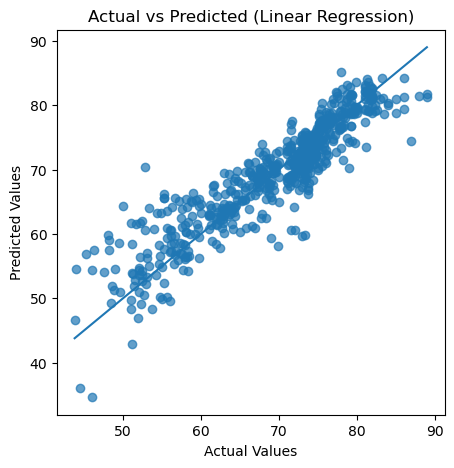

In [62]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_predict, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()])

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

The model shows strong predictive performance, as the predicted values
closely match the actual life expectancy values.
The tight clustering around the identity line suggests a good fit
with minimal systematic error.